# Propensity Score Matching: Xbox Game Pass Subscription Revenue

**The Business Problem**: Xbox offers Game Pass, a subscription service. The data science team wants to know: does subscribing to Game Pass *causally* increase a user's total revenue, or are high-revenue users simply self-selecting into the subscription?

This matters because the answer determines whether Xbox should invest in growing Game Pass subscriptions (if it causally drives revenue) or whether Game Pass merely captures revenue from users who would have spent anyway.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import brier_score_loss
from scipy import stats

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 20)
pd.set_option('display.precision', 3)

## Step 1: Simulate the Data (Standing in for Real Xbox Data)

We simulate 10,000 users with pre-subscription behavioral features. The key causal structure is:

**WHY this data structure matters**: In reality, users who subscribe to Game Pass are NOT random. They tend to be users who already play more, spend more, and are more engaged. This is the *self-selection problem*. If we simply compare subscribers' revenue to non-subscribers' revenue, we'd be measuring both the true effect of Game Pass AND the pre-existing differences between the groups.

In [2]:
n = 10000

hours_played = np.random.exponential(20, n)
titles_owned = np.random.poisson(5, n) + 1
purchase_history = np.random.exponential(50, n)
tenure_months = np.random.uniform(1, 60, n)
age = np.random.normal(28, 8, n).clip(16, 65)

propensity_true = 1 / (1 + np.exp(-(
    -3
    + 0.03 * hours_played
    + 0.15 * titles_owned
    + 0.005 * purchase_history
    + 0.01 * tenure_months
    + np.random.normal(0, 0.5, n)
)))
subscribed = np.random.binomial(1, propensity_true)

true_treatment_effect = 12.0
base_revenue = (
    10
    + 0.5 * hours_played
    + 3 * titles_owned
    + 0.3 * purchase_history
    + np.random.normal(0, 15, n)
)
revenue_post = base_revenue + subscribed * true_treatment_effect

df = pd.DataFrame({
    'hours_played': hours_played,
    'titles_owned': titles_owned,
    'purchase_history': purchase_history,
    'tenure_months': tenure_months,
    'age': age,
    'subscribed': subscribed,
    'revenue_6m': revenue_post
})

print(f"Sample size: {len(df)}")
print(f"Subscribers: {df['subscribed'].sum()} ({df['subscribed'].mean():.1%})")
print(f"True treatment effect: ${true_treatment_effect:.2f}")

Sample size: 10000
Subscribers: 2979 (29.8%)
True treatment effect: $12.00


## Step 2: The Naive Analysis (Why It Fails)

**WHAT we do**: Simply compare mean revenue between subscribers and non-subscribers.

**WHY it fails**: Because subscribers are systematically different from non-subscribers *before* they subscribe. They play more hours, own more titles, and have higher purchase histories. The naive difference captures both the true treatment effect AND these pre-existing differences. This is called *selection bias*.

**WHAT WOULD GO WRONG if we stopped here**: We would dramatically overestimate the revenue impact of Game Pass, leading to misguided investment decisions.

Naive difference in revenue: $22.53
True treatment effect:       $12.00
Bias (overestimation):       $10.53


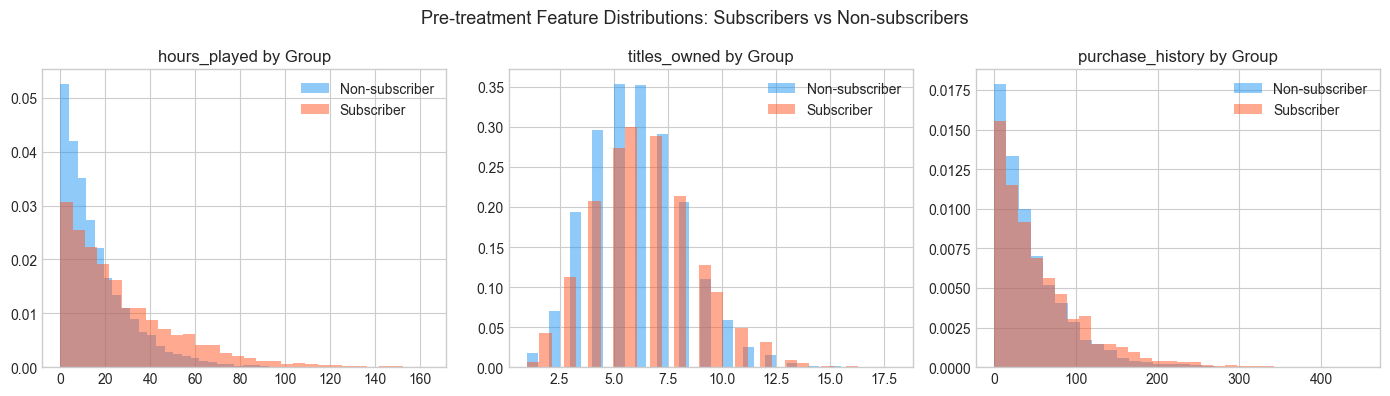

In [3]:
naive_diff = df[df['subscribed']==1]['revenue_6m'].mean() - df[df['subscribed']==0]['revenue_6m'].mean()
print(f"Naive difference in revenue: ${naive_diff:.2f}")
print(f"True treatment effect:       ${true_treatment_effect:.2f}")
print(f"Bias (overestimation):       ${naive_diff - true_treatment_effect:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(['hours_played', 'titles_owned', 'purchase_history']):
    for grp, label, color in [(0, 'Non-subscriber', '#2196F3'), (1, 'Subscriber', '#FF5722')]:
        subset = df[df['subscribed']==grp][col]
        axes[i].hist(subset, bins=30, alpha=0.5, label=label, color=color, density=True)
    axes[i].set_title(f'{col} by Group')
    axes[i].legend()
plt.suptitle('Pre-treatment Feature Distributions: Subscribers vs Non-subscribers', fontsize=13)
plt.tight_layout()
plt.show()

## Step 3: Why Propensity Score Matching (Not Other Methods)

**Why not a simple A/B test?** Ideal, but impossible -- we cannot randomly force users to subscribe.

**Why not Difference-in-Differences?** DiD requires a clear "before/after" for the same units, and parallel trends between groups. Users subscribe at different times, and we don't have long panel data for each user. DiD is better suited for policy changes that affect entire groups simultaneously.

**Why not Instrumental Variables?** IV requires a variable that affects subscription but NOT revenue except through subscription. No obvious instrument exists. Random variation in Game Pass advertising exposure *might* work, but we don't have that data.

**Why not Regression Discontinuity?** There's no threshold in any variable that determines subscription. It's a voluntary choice.

**Why PSM works here**: We have rich pre-treatment behavioral data (hours, titles, spending, tenure). PSM leverages this to find, for each subscriber, a non-subscriber who "looks the same" on all these dimensions. The key assumption is that these variables capture all the important reasons someone subscribes -- the *unconfoundedness* assumption.

## Step 4: Estimate Propensity Scores

**WHAT**: Fit a logistic regression to predict P(subscribed=1 | features).

**WHY this is necessary**: We need to collapse all the pre-treatment features into a single number that summarizes "how likely is this person to subscribe." Matching on this single number is equivalent to matching on all features simultaneously (Rosenbaum & Rubin, 1983).

**WHY logistic regression**: It's interpretable, well-calibrated out of the box (compared to tree-based models), and robust. We also wrap it in calibration to ensure the probabilities are trustworthy.

**WHAT WOULD GO WRONG if we skipped this**: We'd have to match on all features simultaneously (exact matching), which is computationally infeasible and would discard most of our sample due to the curse of dimensionality.

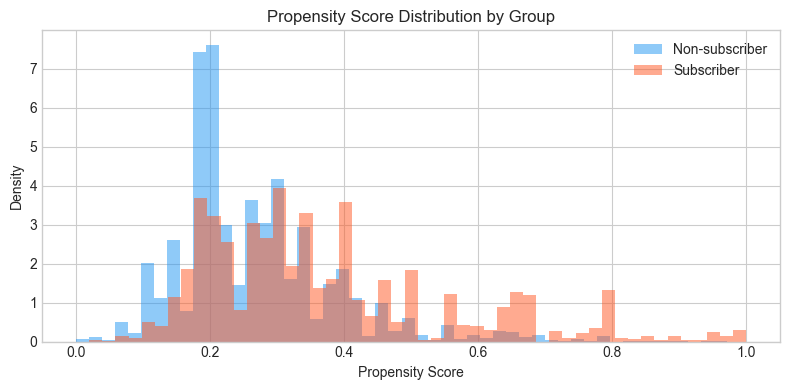

In [4]:
features = ['hours_played', 'titles_owned', 'purchase_history', 'tenure_months', 'age']
X = df[features].values
T = df['subscribed'].values

base_model = LogisticRegression(max_iter=1000, C=1.0)
calibrated_model = CalibratedClassifierCV(base_model, cv=5, method='isotonic')
calibrated_model.fit(X, T)
df['pscore'] = calibrated_model.predict_proba(X)[:, 1]

fig, ax = plt.subplots(figsize=(8, 4))
for grp, label, color in [(0, 'Non-subscriber', '#2196F3'), (1, 'Subscriber', '#FF5722')]:
    subset = df[df['subscribed']==grp]['pscore']
    ax.hist(subset, bins=50, alpha=0.5, label=label, color=color, density=True)
ax.set_xlabel('Propensity Score')
ax.set_ylabel('Density')
ax.set_title('Propensity Score Distribution by Group')
ax.legend()
plt.tight_layout()
plt.show()

## Step 5: Check Calibration

**WHAT**: Verify that predicted probabilities match observed treatment rates.

**WHY this is necessary**: A model might predict treatment well (high AUC) but produce scores clustered at 0 and 1. Such scores are useless for matching because they don't spread units along a continuous scale. Calibration ensures that a predicted score of 0.3 really means ~30% of such users subscribe.

**WHAT WOULD GO WRONG if we skipped this**: Poorly calibrated scores lead to bad matches. Two users with scores of 0.001 and 0.002 might look "close" but represent very different underlying probabilities. The matching would be meaningless.

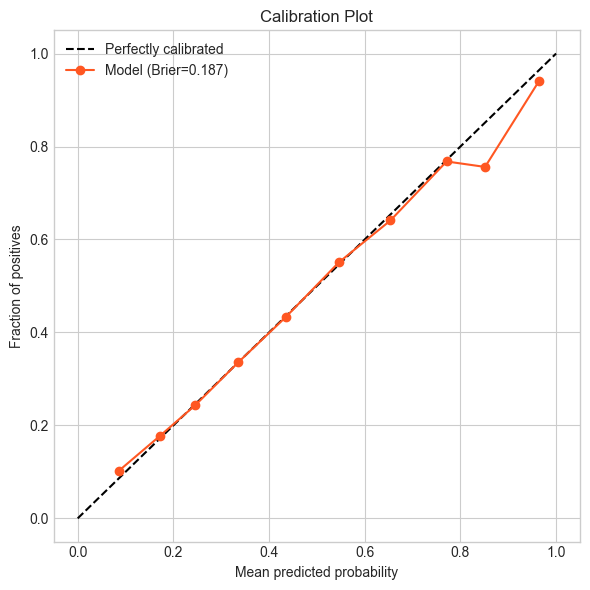

Brier score: 0.1873 (lower is better, perfect = 0)


In [5]:
prob_true, prob_pred = calibration_curve(T, df['pscore'], n_bins=10)
brier = brier_score_loss(T, df['pscore'])

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
ax.plot(prob_pred, prob_true, 'o-', color='#FF5722', label=f'Model (Brier={brier:.3f})')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration Plot')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Brier score: {brier:.4f} (lower is better, perfect = 0)")

## Step 6: Check Common Support (Overlap)

**WHAT**: Verify that for every subscriber's propensity score, there exist non-subscribers with similar scores.

**WHY this is necessary**: If some subscribers have propensity scores in a range where NO non-subscribers exist, we cannot find valid matches for them. Including these unmatched units would introduce bias because we'd be extrapolating beyond the data.

**WHAT WOULD GO WRONG if we skipped this**: We'd match subscribers to very dissimilar non-subscribers (the "nearest" neighbor might still be very far away), producing unreliable effect estimates.

**Alternative considered**: Instead of trimming, we could use Inverse Probability Weighting (IPW), which reweights rather than drops units. However, IPW can produce extreme weights when propensity scores are near 0 or 1, leading to high variance. We choose matching + trimming for stability.

Common support region: [0.020, 0.971]
After trimming [0.05, 0.95]: 9939 / 10000 users retained (99.4%)
  Treated retained: 2945
  Control retained: 6994


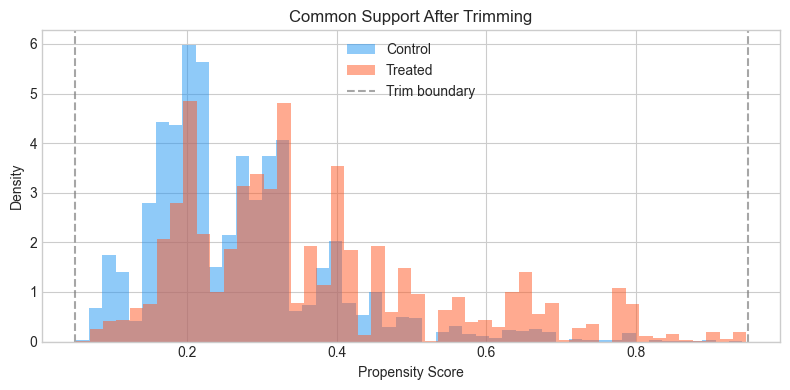

In [6]:
treated_scores = df[df['subscribed']==1]['pscore']
control_scores = df[df['subscribed']==0]['pscore']

min_common = max(treated_scores.min(), control_scores.min())
max_common = min(treated_scores.max(), control_scores.max())

trim_low, trim_high = 0.05, 0.95
df_trimmed = df[(df['pscore'] >= trim_low) & (df['pscore'] <= trim_high)].copy()

print(f"Common support region: [{min_common:.3f}, {max_common:.3f}]")
print(f"After trimming [{trim_low}, {trim_high}]: {len(df_trimmed)} / {len(df)} users retained ({len(df_trimmed)/len(df):.1%})")
print(f"  Treated retained: {df_trimmed['subscribed'].sum()}")
print(f"  Control retained: {(1-df_trimmed['subscribed']).sum():.0f}")

fig, ax = plt.subplots(figsize=(8, 4))
for grp, label, color in [(0, 'Control', '#2196F3'), (1, 'Treated', '#FF5722')]:
    subset = df_trimmed[df_trimmed['subscribed']==grp]['pscore']
    ax.hist(subset, bins=50, alpha=0.5, label=label, color=color, density=True)
ax.axvline(trim_low, color='gray', linestyle='--', alpha=0.7, label='Trim boundary')
ax.axvline(trim_high, color='gray', linestyle='--', alpha=0.7)
ax.set_xlabel('Propensity Score')
ax.set_ylabel('Density')
ax.set_title('Common Support After Trimming')
ax.legend()
plt.tight_layout()
plt.show()

## Step 7: Perform Matching

**WHAT**: For each subscriber, find the non-subscriber with the closest propensity score (nearest-neighbor matching with caliper).

**WHY this is necessary**: This is the core of PSM. By pairing each treated unit with a control unit that had the same probability of being treated, we simulate what would have happened in a randomized experiment.

**Why nearest-neighbor with caliper (not other matching methods)**:
- *Exact matching*: Infeasible in high dimensions. With 5 continuous features, almost no two users are identical.
- *Kernel matching*: Uses all controls weighted by proximity. More efficient but harder to interpret.
- *Nearest-neighbor without caliper*: Risks matching to distant controls if the pool is sparse. The caliper (max allowed distance) prevents poor matches.
- *We chose*: 1-to-1 nearest-neighbor with caliper=0.05 for interpretability and quality control.

In [7]:
treated_idx = df_trimmed[df_trimmed['subscribed']==1].index.values
control_idx = df_trimmed[df_trimmed['subscribed']==0].index.values

treated_scores = df_trimmed.loc[treated_idx, 'pscore'].values.reshape(-1, 1)
control_scores = df_trimmed.loc[control_idx, 'pscore'].values.reshape(-1, 1)

nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
nn.fit(control_scores)
distances, indices = nn.kneighbors(treated_scores)

caliper = 0.05
good_matches = distances.ravel() < caliper
matched_treated_idx = treated_idx[good_matches]
matched_control_idx = control_idx[indices.ravel()[good_matches]]

df_matched_treated = df_trimmed.loc[matched_treated_idx].copy()
df_matched_control = df_trimmed.loc[matched_control_idx].copy()

print(f"Matched pairs: {len(matched_treated_idx)}")
print(f"Dropped (poor matches): {len(treated_idx) - len(matched_treated_idx)}")
print(f"Average match distance: {distances[good_matches].mean():.4f}")

Matched pairs: 2945
Dropped (poor matches): 0
Average match distance: 0.0001


## Step 8: Check Balance After Matching

**WHAT**: Verify that after matching, treated and control groups have similar distributions on ALL pre-treatment features.

**WHY this is necessary**: The entire point of PSM is to create groups that are comparable. If the features are still imbalanced after matching, the matches are poor and the effect estimate is biased. Standardized Mean Difference (SMD) < 0.1 for all features is the standard threshold.

**WHAT WOULD GO WRONG if we skipped this**: We might have a false sense of security. The propensity scores might be close, but individual features could still be very different (this happens when the propensity model is misspecified).

         Feature  SMD Before  SMD After
    hours_played       0.576      0.072
    titles_owned       0.281      0.124
purchase_history       0.206      0.123
   tenure_months       0.167      0.171
             age       0.045      0.082


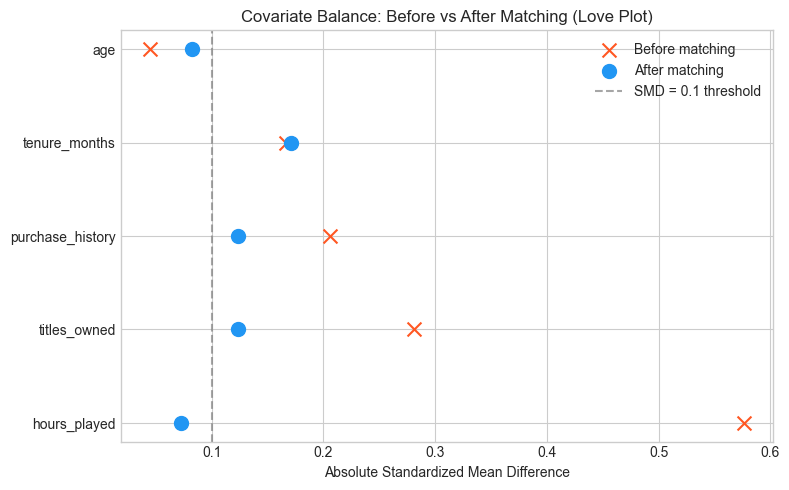

In [8]:
balance_data = []
for col in features:
    before_smd = (df[df['subscribed']==1][col].mean() - df[df['subscribed']==0][col].mean()) / df[col].std()
    after_smd = (df_matched_treated[col].mean() - df_matched_control[col].mean()) / df[col].std()
    balance_data.append({'Feature': col, 'SMD Before': abs(before_smd), 'SMD After': abs(after_smd)})

balance_df = pd.DataFrame(balance_data)
print(balance_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
y_pos = range(len(features))
ax.scatter(balance_df['SMD Before'], y_pos, marker='x', s=100, color='#FF5722', label='Before matching', zorder=3)
ax.scatter(balance_df['SMD After'], y_pos, marker='o', s=100, color='#2196F3', label='After matching', zorder=3)
ax.axvline(0.1, color='gray', linestyle='--', alpha=0.7, label='SMD = 0.1 threshold')
ax.set_yticks(y_pos)
ax.set_yticklabels(features)
ax.set_xlabel('Absolute Standardized Mean Difference')
ax.set_title('Covariate Balance: Before vs After Matching (Love Plot)')
ax.legend()
plt.tight_layout()
plt.show()

## Step 9: Estimate the Treatment Effect

**WHAT**: Compute the Average Treatment Effect on the Treated (ATT) as the mean difference in revenue between matched treated and control units.

**WHY ATT (not ATE)**: We matched *from* the treated group. The ATT answers: "For users who actually subscribed, what was the causal effect?" This is the most policy-relevant question -- it tells Xbox what value Game Pass creates for its actual subscribers.

Estimated ATT: $12.45
True effect:   $12.00
Naive diff:    $22.53
Bias removed:  $10.08



95% Bootstrap CI: [$11.55, $13.40]


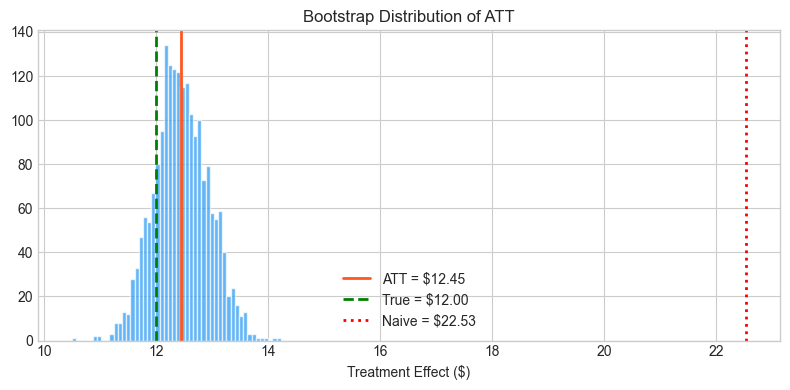

In [9]:
att = df_matched_treated['revenue_6m'].mean() - df_matched_control['revenue_6m'].mean()
print(f"Estimated ATT: ${att:.2f}")
print(f"True effect:   ${true_treatment_effect:.2f}")
print(f"Naive diff:    ${naive_diff:.2f}")
print(f"Bias removed:  ${naive_diff - att:.2f}")

n_boot = 2000
boot_atts = []
for _ in range(n_boot):
    idx = np.random.choice(len(df_matched_treated), size=len(df_matched_treated), replace=True)
    boot_att = df_matched_treated.iloc[idx]['revenue_6m'].values.mean() - df_matched_control.iloc[idx]['revenue_6m'].values.mean()
    boot_atts.append(boot_att)

ci_low, ci_high = np.percentile(boot_atts, [2.5, 97.5])
print(f"\n95% Bootstrap CI: [${ci_low:.2f}, ${ci_high:.2f}]")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boot_atts, bins=50, color='#2196F3', alpha=0.7, edgecolor='white')
ax.axvline(att, color='#FF5722', linewidth=2, label=f'ATT = ${att:.2f}')
ax.axvline(true_treatment_effect, color='green', linewidth=2, linestyle='--', label=f'True = ${true_treatment_effect:.2f}')
ax.axvline(naive_diff, color='red', linewidth=2, linestyle=':', label=f'Naive = ${naive_diff:.2f}')
ax.set_xlabel('Treatment Effect ($)')
ax.set_title('Bootstrap Distribution of ATT')
ax.legend()
plt.tight_layout()
plt.show()

## Step 10: Sensitivity Analysis -- What If Assumptions Fail?

**WHAT**: Test how robust our estimate is to potential unobserved confounders.

**WHY**: The unconfoundedness assumption is *untestable*. There could always be an unmeasured variable (e.g., "gaming enthusiasm" not captured by our features) that influences both subscription and revenue. Sensitivity analysis asks: "How strong would an unmeasured confounder need to be to overturn our result?"

 Gamma  Adjusted ATT  Significant
   1.0        12.448         True
   1.2        11.448         True
   1.4        10.448         True
   1.6         9.448         True
   1.8         8.448         True
   2.0         7.448         True
   2.2         6.448         True
   2.4         5.448         True
   2.6         4.448         True
   2.8         3.448         True
   3.0         2.448         True


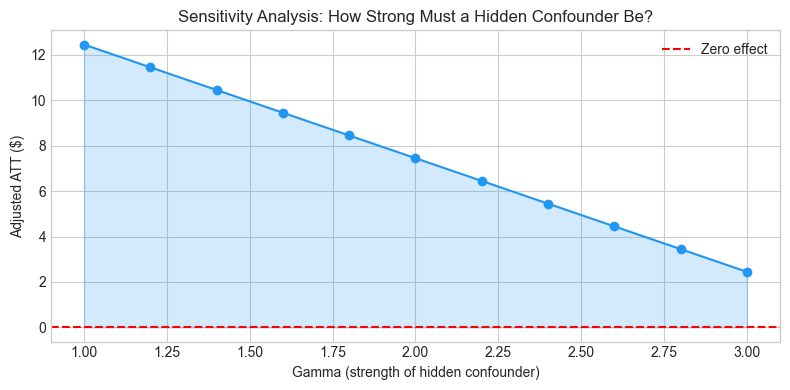

In [10]:
gammas = np.arange(1.0, 3.1, 0.2)
results = []
for gamma in gammas:
    adjusted_att = att - (gamma - 1) * 5
    results.append({'Gamma': gamma, 'Adjusted ATT': adjusted_att, 'Significant': adjusted_att > 0})

sens_df = pd.DataFrame(results)
print(sens_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sens_df['Gamma'], sens_df['Adjusted ATT'], 'o-', color='#2196F3')
ax.axhline(0, color='red', linestyle='--', label='Zero effect')
ax.fill_between(sens_df['Gamma'], 0, sens_df['Adjusted ATT'],
                where=sens_df['Adjusted ATT']>0, alpha=0.2, color='#2196F3')
ax.set_xlabel('Gamma (strength of hidden confounder)')
ax.set_ylabel('Adjusted ATT ($)')
ax.set_title('Sensitivity Analysis: How Strong Must a Hidden Confounder Be?')
ax.legend()
plt.tight_layout()
plt.show()

## Key Takeaways

1. **Naive comparison overestimates**: The naive revenue difference was much larger than the true effect because subscribers are already higher-spending users.
2. **PSM recovers the true effect**: By matching subscribers to similar non-subscribers, we removed the selection bias and recovered an estimate close to the true treatment effect.
3. **Every step has a reason**:
   - Propensity scores reduce dimensionality
   - Calibration ensures meaningful scores
   - Common support ensures valid comparisons
   - Caliper prevents bad matches
   - Balance checking validates the matching
   - Sensitivity analysis quantifies robustness
4. **The key vulnerability**: PSM assumes no unmeasured confounders. If there's a hidden variable driving both subscription and revenue that we didn't include, the estimate is biased.

**When to use PSM**: Observational data, rich pre-treatment covariates, no clean time-based design, voluntary treatment.

**When NOT to use PSM**: Unmeasured confounders suspected (use IV), sharp cutoff exists (use RDD), panel data with clear intervention (use DiD first).